In [1]:
import pandas as pd
import numpy as np # Calculos otimizados 

In [2]:
# Em alguns casos não tem o link
url = 'https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv' # Se você usa URL não precisa de CSV, e assim o CSV sempre vai atualizar em tempo real. 
# Cisp == num DP; MCIRC == codigo do municipio do IBGE; 

df = pd.read_csv(url, encoding='latin1', sep=';') # Na maioria dos casos quando o UTF-8 não é o encoder o latin1 é a solução
# .head(), é usado para testes e puxa somente a quantidade de linhas que você quer. Sem nenhum parametro ele chama 5 linhas; .tail(), é o inverso do head.
# .columns lista colunas; .info() diz a coluna e a quantidade de dados não nulos e tipo de dados de cada coluna
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'feminicidio', 'letalidade_violenta',
       'tentat_hom', 'tentativa_feminicidio', 'lesao_corp_dolosa', 'estupro',
       'hom_culposo', 'lesao_corp_culposa', 'roubo_transeunte',
       'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo',
       'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco',
       'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque',
       'roubo_bicicleta', 'outros_roubos', 'total_roubos', 'furto_veiculos',
       'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', '

In [3]:
# Qualitativo no parentese e quantitativo colchete, reset_index() faz com que o index não seja o valor qualitativo
df_furto_cel_dp = df.groupby('cisp')['furto_celular'].sum().reset_index() 
df_furto_cel_dp = df_furto_cel_dp.sort_values(by='furto_celular', ascending= False) # ascending define a relação, default vem true (crescente e decrescente)
df_furto_cel_dp

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
...,...,...
41,45,73
77,92,65
114,138,56
131,157,55


In [4]:
df_ap_menores_dp = df.groupby('cisp')[['aaapai', 'cmba']].sum().reset_index()
df_ap_menores_dp.sort_values(by='aaapai', ascending= False, inplace=True) # Inplace deixa a mudança permanente, isso ajuda a não repetir a igualdade df = df 
df_ap_menores_dp


,cisp,aaapai,cmba
104,126,3736.0,119.0
8,12,3667.0,1090.0
10,14,3368.0,731.0
65,74,3355.0,192.0
12,16,3233.0,853.0
...,...,...,...
130,156,19.0,4.0
129,155,16.0,3.0
131,157,14.0,3.0
94,111,13.0,3.0


In [5]:
df_roubo_vei_dp = df.groupby('cisp')['roubo_veiculo'].sum().reset_index()
df_roubo_vei_dp = df_roubo_vei_dp.sort_values(by='roubo_veiculo', ascending=False)
df_roubo_vei_dp

,cisp,roubo_veiculo
52,59,37866
57,64,32892
35,39,29753
23,27,27978
30,34,27596
...,...,...
77,92,8
116,140,8
115,139,7
113,137,6


In [6]:
# Filtros diferentes: 
df_capital = df[df['munic'] == 'Rio de Janeiro'] # Dataframe onde a coluna de munic é apenas a capital
# Esses dois tem o desempenho melhor
df_capital = df.query("munic == 'Rio de Janeiro'") # Query onde a condicional inteira está em string, mais complicado porque é fácil de se confundir com as aspas
df_capital = df.loc[df['munic'] == 'Rio de Janeiro'] # Mesma coisa que o primeiro, só que o loc é melhor porque tem a sintaxe parecida com outras.

df_furto_cel_dp_capital = df_capital.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto_cel_dp_capital.sort_values(by='furto_celular', ascending=False, inplace=True)
df_furto_cel_dp_capital

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
5,9,15367
6,10,14842
14,18,14504
1,4,14339
28,32,12898


In [7]:
munic_pedido = ['Belford Roxo', 'Nova Iguaçu', 'Queimados']
# isin é feito para fazer um filtro usando uma lista com base, o separador de condições é '&' e as condições ficam em parenteses 
df_bel_nov_quei = df.loc[((df['munic'].isin(munic_pedido)) & (df['ano'] == 2025))]

df_roxo_furto_cel_dp = df_bel_nov_quei.groupby('cisp')['furto_celular'].sum().reset_index()
df_roxo_furto_cel_dp.sort_values(by='furto_celular', ascending=False, inplace=True)
df_roxo_furto_cel_dp

,cisp,furto_celular
0,52,519
4,58,188
3,56,123
1,54,112
2,55,96


In [8]:
array_furto_cel_dp = np.array(df_furto_cel_dp['furto_celular']) # array para os calculos de np

media = np.mean(array_furto_cel_dp)
mediana = np.median(array_furto_cel_dp) # Mesma mediana da escola
# Quartis: São as porcentagens no caso linhas de corte, q1(25%), q2(50% e sempre vai ser igual a mediana) e q3(75%). 
# Eles são chamados de quartis porque dividem em 4 parcelas de 25%
# Se você muda a porcentagem ele deixa de ser um quatil e passa a ser uma análise pessoal
q1 = np.percentile(array_furto_cel_dp, 25)
q2 = np.percentile(array_furto_cel_dp, 50)
q3 = np.percentile(array_furto_cel_dp, 75)
print(f'Média: {media}\nMediana: {mediana}')
print(f'Q1: {q1} \nQ2: {q2} \nQ3: {q3}')

Média: 3554.4347826086955
Mediana: 1741.5
Q1: 455.75 
Q2: 1741.5 
Q3: 4712.25


In [9]:
df_furto_cel_acima_q3 = df_furto_cel_dp.loc[df_furto_cel_dp['furto_celular'] > q3] 
df_furto_cel_acima_q3 = df_furto_cel_dp.query('furto_celular > @q3') # No query você precisa usar @ para chamar uma variavel
df_furto_cel_acima_q3

,cisp,furto_celular
12,16,26230
2,5,25737
10,14,19004
8,12,17630
0,1,16185
5,9,15367
6,10,14842
14,18,14504
1,4,14339
28,32,12898


## Graficos da AULA AVANÇADA que tem um número que eu esqueci

In [12]:
df_veiculos = df.groupby('cisp')[['furto_veiculos', 'roubo_veiculo', 'recuperacao_veiculos']].sum().reset_index()
df_veiculos = df_veiculos.sort_values(by='cisp')
df_veiculos.head(2)

,cisp,furto_veiculos,roubo_veiculo,recuperacao_veiculos
0,1,1945,583,548
1,4,1274,2223,1937


In [13]:
corr_pandas = df_veiculos[['furto_veiculos', 'roubo_veiculo', 'recuperacao_veiculos']].corr()
corr_pandas

,furto_veiculos,roubo_veiculo,recuperacao_veiculos
furto_veiculos,1.000000,0.773692,0.706661
roubo_veiculo,0.773692,1.000000,0.927230
recuperacao_veiculos,0.706661,0.927230,1.000000


<Axes: >

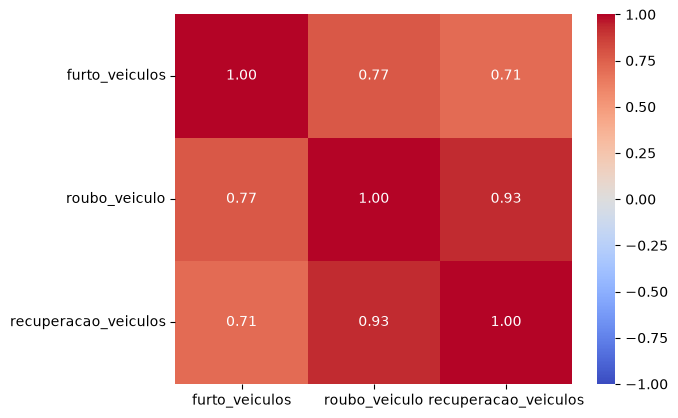

In [14]:
import seaborn as sns
sns.heatmap(corr_pandas, 
            annot=True, # Valores dentro das caixas
            cmap='coolwarm', # Cor
            # Valor máximo e mínimo 
            vmin=-1,
            vmax=1,
            # Formatação do valor
            fmt='.2f'
            )

In [15]:
df_roubos = df.groupby('cisp')[['latrocinio','tentat_hom', 'roubo_rua', 'roubo_celular']].sum().reset_index().sort_values(by='cisp')
df_roubos.head()

,cisp,latrocinio,tentat_hom,roubo_rua,roubo_celular
0,1,19,123,22790,4724
1,4,18,854,27988,4970
2,5,22,381,42638,8857
3,6,26,1219,18904,2978
4,7,9,533,6338,868


In [17]:
corr_pandas = df_roubos[['latrocinio','tentat_hom', 'roubo_rua', 'roubo_celular']].corr()

<Axes: >

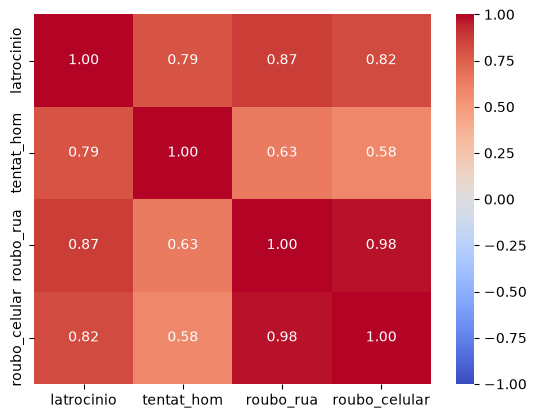

In [18]:
sns.heatmap(corr_pandas, 
            annot=True, # Valores dentro das caixas
            cmap='coolwarm', # Cor
            # Valor máximo e mínimo 
            vmin=-1,
            vmax=1,
            # Formatação do valor
            fmt='.2f'
            )

In [21]:
df_drogas = df.groupby('cisp')[['apreensao_drogas', 'posse_drogas', 'trafico_drogas']].sum().reset_index().sort_values(by='cisp')
df_drogas.head(3)

,cisp,apreensao_drogas,posse_drogas,trafico_drogas
0,1,1293,859.0,301.0
1,4,5843,2729.0,1571.0
2,5,6792,4544.0,1626.0


In [26]:
array_ap = np.array(df_drogas['apreensao_drogas'])
array_po = np.array(df_drogas['posse_drogas'])
array_tra = np.array(df_drogas['trafico_drogas'])